# Real-data robustness study: one figure per property

Reads `results/real_robustness/` produced by

```bash
python run_real_data.py --study robustness --sweep all --seeds 0:50 --workers 12
python run_real_data.py --study robustness --clean-fit   # judge-level position effects (main figure, panel d)
```

Design: `code/plan/2026-09-06-real-data-robustness-plan.md` (Section 22) and `2026-09-07-real-data-presentation-plan.md` (Section 9). Metric: excess held-out human log loss over the test-pool BTL floor (continuous, comparable across the three benchmarks) and, on Chatbot Arena only, Kendall $\tau$ with the held-out human ranking (MT-Bench and PandaLM have 15 and 10 pairs, so $\tau$ moves in steps of 0.13 and 0.2 and saturates). Bars and bands are $\pm1.96$ Monte Carlo s.e. over seeds.
Methods: Human; Pooled (no judge structure, no order term, scale calibrated); Cons-Cal (two-step, $s=\alpha\widehat\mu$); DIAL ($\mu$ aligned to the human comparisons, $V$ on the LLM side, GACV weight); DIAL-noPos (DIAL without the order term). DIAL-W and the fixed-weight variants are appendix diagnostics.

In [1]:
import sys, json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt

REPO = Path.cwd().parent; sys.path.insert(0, str(REPO))
from experiments.real_data.robustness_plot import load, aggregate, aggregate_spectest
RESULTS = REPO / "results" / "real_robustness"; FIGURES = REPO / "figures"; FIGURES.mkdir(exist_ok=True)
DATASETS = ["arena_33k", "mt_bench", "pandalm"]
# Shared method panel and drawing helpers (experiments/style.py): five presented methods plus
# appendix diagnostics, one seaborn call per panel.
from experiments.style import (PRESENTED, PRESENTED_W, APPENDIX, LABEL, STYLE, INK, INK_SOFT, GRID, RCPARAMS,
                               DATASET_LABEL as DLAB, DATASET_COLOR, legend_handles, method_bars, method_lines)
METHODS = list(PRESENTED)
NH = "$n_{\\mathrm{H}}$"  # human budget, as written in the manuscript
mpl.rcParams.update(RCPARAMS)

rows = {d: load(d, REPO) for d in DATASETS if (RESULTS / d / "rows.jsonl").exists()}
agg = {d: aggregate(df) for d, df in rows.items()}
spec = aggregate_spectest(rows["arena_33k"]) if "arena_33k" in rows else pd.DataFrame()
for d, df in rows.items():
    ok = df[(~df.failed) & (~df.method.isin(["spectest", "planner"]))]
    print(f"{DLAB[d]:<14} seeds={df.seed.nunique()}  rows={len(df)}  failed={int(df.failed.sum())}  non-converged={int((~ok.converged.fillna(True).astype(bool)).sum())}")
if any(rows[d].failed.any() for d in rows):
    print(pd.concat(rows.values())[lambda x: x.failed].groupby(["dataset", "sweep", "panel", "level", "method"]).size().to_string())


Chatbot Arena  seeds=50  rows=31350  failed=0  non-converged=260
MT-Bench       seeds=50  rows=24500  failed=0  non-converged=557
PandaLM        seeds=50  rows=24500  failed=0  non-converged=834


In [2]:
def curve(ax, a, sweep, panel, kind, methods, x="level", n_H_level=None, logx=False, hline_human=True, band=True, metric="excess"):
    """One panel of the curve figures: `method_lines` for the methods, human-only as a flat line
    when the x axis is not the human budget itself."""
    g = a[(a.sweep == sweep) & (a.panel == panel) & (a.kind == kind)]
    if n_H_level is not None: g = g[g.n_H_level == n_H_level]
    if g.empty: ax.text(0.5, 0.5, "not run", ha="center", va="center", transform=ax.transAxes, color=INK_SOFT); return
    g = g.assign(_x=g["n_H_mean"] if x == "n_H" else g["level"])
    if hline_human and x != "n_H" and (g.method == "human_only").any():
        ax.axhline(g.loc[g.method == "human_only", f"{metric}_mean"].mean(), color=STYLE["human_only"]["color"], ls="-", lw=1.0)
        methods = [m for m in methods if m != "human_only"]
    method_lines(ax, g, "_x", f"{metric}_mean", methods, se=f"{metric}_se", band=band, se_exclude=("human_only",))
    if logx: ax.set_xscale("log"); ax.xaxis.set_minor_formatter(mpl.ticker.NullFormatter())
    ax.grid(True, color=GRID, lw=0.5); ax.tick_params(length=2.5)

def clip_axis(ax, a, sweep, panel, kind, methods, n_H_level=None, top=None):
    g = a[(a.sweep == sweep) & (a.panel == panel) & (a.kind == kind) & (a.method.isin(methods))]
    if n_H_level is not None: g = g[g.n_H_level == n_H_level]
    lo = g.excess_mean.min(); hi = g.excess_mean.max() if top is None else min(g.excess_mean.max(), lo + top)
    ax.set_ylim(lo - 0.15 * (hi - lo), hi + 0.1 * (hi - lo))

# Figure 3 draws both alignments, in the shared order of `style.PRESENTED_W` (human-only is a line, not a bar)
BAR_METHODS = [m for m in PRESENTED_W if m != "human_only"]

def cell_of(a, q):
    g = a[(a.sweep == q["sweep"]) & (a.panel == q["panel"]) & (a.kind == q["kind"]) & np.isclose(a.level, q["level"])]
    if q.get("n_H_level") is not None: g = g[g.n_H_level == q["n_H_level"]]
    return g

SEP_HATCH_AT = 0.5   # hatch a bar when the fit touched the finite-fit box (a separated judge) in at least this share of splits

def bar_panel(ax, a, specs, methods=BAR_METHODS, metric="excess", human=True):
    """Grouped bars: one group per level in `specs` (label, query), one bar per method; human-only as a line.
    Hatched bars: the LLM-side or joint fit had a coordinate on the finite-fit box in >= SEP_HATCH_AT of the splits
    (the LLM MLE does not exist there; the score is the bounded maximizer)."""
    labels = [lab for lab, _ in specs]
    d = pd.concat([cell_of(a, q).assign(group=lab) for lab, q in specs], ignore_index=True)
    d["separated"] = d["sep_frac"].fillna(0) >= SEP_HATCH_AT
    method_bars(ax, d, "group", f"{metric}_mean", methods, se=f"{metric}_se", hatch="separated", order=labels)
    hvals = d.loc[d.method == "human_only", f"{metric}_mean"]
    if human and len(hvals): ax.axhline(hvals.mean(), color=STYLE["human_only"]["color"], lw=1.0, zorder=1)
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, fontsize=7); ax.set_xlim(-0.55, len(labels) - 0.45)
    ax.grid(True, axis="y", color=GRID, lw=0.5); ax.tick_params(length=2.5); ax.set_axisbelow(True)

# the three levels of each main-figure row, per dataset (biased-five panel throughout)
NH_ABUNDANT = {"arena_33k": 300, "mt_bench": 80, "pandalm": 60}          # default calibration size (order and abundant-injection sweeps)
NH_SCARCE = {"arena_33k": 1000, "mt_bench": 80, "pandalm": 60}           # noise_scarce n_H_fixed and the llm_budget n_H level used
NL_ABUNDANT = {"arena_33k": 20000, "mt_bench": 1600, "pandalm": 1000}    # largest llm_budget level
NL_SCARCE = {"arena_33k": 2000, "mt_bench": 160, "pandalm": 100}         # noise_scarce base sample (about ten judgments per pair)

def row1_specs(d):
    return [("balanced", dict(sweep="order", panel="biased5", kind="none", level=1.0)),
            ("one-sided", dict(sweep="order", panel="biased5", kind="none", level=0.05)),
            ("one-sided\n+8 position judges", dict(sweep="noise", panel="biased5", kind="position", level=8))]

def row2_specs(d):
    return [(f"abundant\n$n_{{\\mathrm{{L}}}}$={NL_ABUNDANT[d]:,}", dict(sweep="llm_budget", panel="biased5", kind="none", level=NL_ABUNDANT[d], n_H_level=NH_SCARCE[d])),
            (f"scarce\n$n_{{\\mathrm{{L}}}}$={NL_SCARCE[d]:,}", dict(sweep="noise_scarce", panel="biased5", kind="anti", level=0)),
            ("scarce\n+4 anti-consensus", dict(sweep="noise_scarce", panel="biased5", kind="anti", level=4))]


## Main-text figure (2 x 4)

Columns 1 to 3: Chatbot Arena, MT-Bench, PandaLM, with the five position-sensitive judges; grouped bars over three levels (five estimators per group), excess held-out log loss, human-only BTL as a line.
Row 1, position debiasing: balanced display; one-sided display (5% swapped copies); one-sided display plus 8 injected position-only judges. Pooled and DIAL-noPos rise, DIAL-$\mu$, DIAL-$W$, and Cons-Cal do not.
Row 2, adaptive weighting and robustness: abundant LLM data (largest $n_{\mathrm{L}}$ level); scarce LLM data (about ten judgments per pair); scarce plus 4 injected anti-consensus judges. DIAL-$\mu$ equals Cons-Cal when abundant, beats it when scarce, and holds when the LLM panel is corrupted; DIAL-$W$ tracks it a little above.
Column 4: judge-level position effects on the three datasets (row 1) and the specification test of $s_0=\alpha\mu$ on Chatbot Arena, the only benchmark with a covariate that defines a subpopulation (row 2).

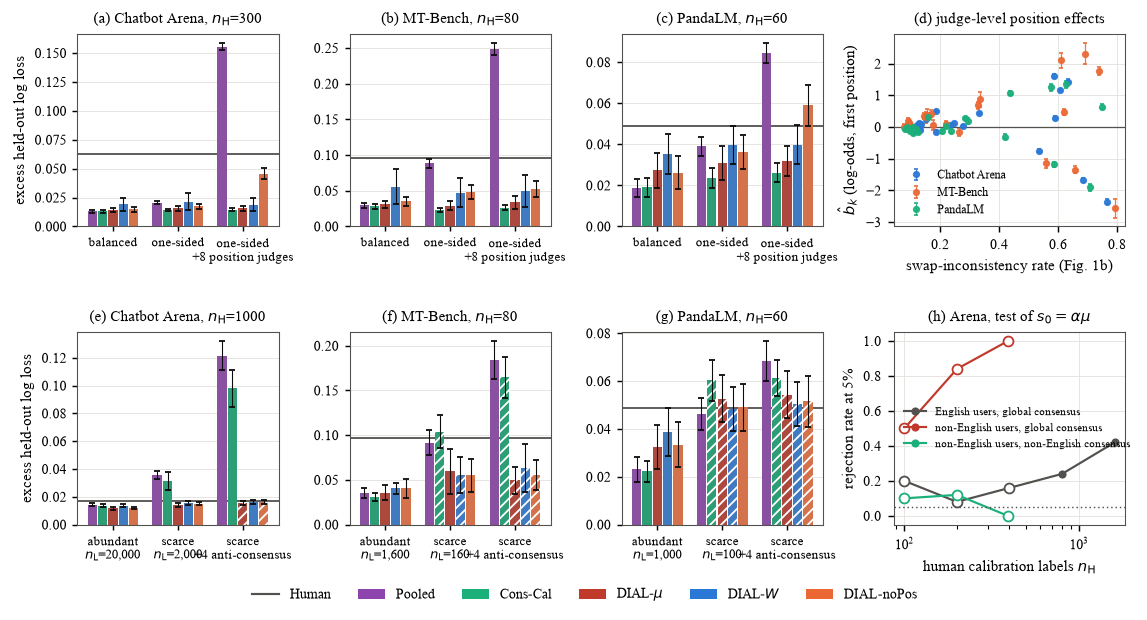

n   Human  Pooled  \
dataset       row       level                                                  
Chatbot Arena position  balanced                          50  0.0625  0.0131   
                        one-sided                         50  0.0625  0.0205   
                        one-sided +8 position judges      50  0.0625  0.1555   
              weighting abundant $n_{\mathrm{L}}$=20,000  50  0.0169  0.0143   
                        scarce $n_{\mathrm{L}}$=2,000     50  0.0169  0.0360   
                        scarce +4 anti-consensus          50  0.0169  0.1214   
MT-Bench      position  balanced                          50  0.0966  0.0296   
                        one-sided                         50  0.0966  0.0883   
                        one-sided +8 position judges      50  0.0966  0.2483   
              weighting abundant $n_{\mathrm{L}}$=1,600   50  0.0966  0.0352   
                        scarce $n_{\mathrm{L}}$=160       50  0.0966  0.0918   
                        scarce +4 anti-consensus          50  0.0966  0.1838   
PandaLM       position  balanced                          50  0.0489  0.0189   
                        one-sided                         50  0.0489  0.0390   
                        one-sided +8 position judges      50  0.0489  0.0844   
              weighting abundant $n_{\mathrm{L}}$=1,000   50  0.0489  0.0232   
                        scarce $n_{\mathrm{L}}$=100       50  0.0489  0.0463   
                        scarce +4 anti-consensus          50  0.0489  0.0683   

                                                         Cons-Cal DIAL-$\mu$  \
dataset       row       level                                                  
Chatbot Arena position  balanced                           0.0131     0.0145   
                        one-sided                          0.0142     0.0158   
                        one-sided +8 position judges       0.0145     0.0158   
              weighting abundant $n_{\mathrm{L}}$=20,000   0.0135     0.0118   
                        scarce $n_{\mathrm{L}}$=2,000      0.0317     0.0143   
                        scarce +4 anti-consensus           0.0982     0.0157   
MT-Bench      position  balanced                           0.0285     0.0310   
                        one-sided                          0.0235     0.0288   
                        one-sided +8 position judges       0.0264     0.0337   
              weighting abundant $n_{\mathrm{L}}$=1,600    0.0309     0.0358   
                        scarce $n_{\mathrm{L}}$=160        0.1040     0.0599   
                        scarce +4 anti-consensus           0.1648     0.0494   
PandaLM       position  balanced                           0.0190     0.0273   
                        one-sided                          0.0237     0.0310   
                        one-sided +8 position judges       0.0262     0.0319   
              weighting abundant $n_{\mathrm{L}}$=1,000    0.0222     0.0325   
                        scarce $n_{\mathrm{L}}$=100        0.0603     0.0526   
                        scarce +4 anti-consensus           0.0613     0.0544   

                                                         DIAL-$W$ DIAL-noPos  
dataset       row       level                                                 
Chatbot Arena position  balanced                           0.0191     0.0147  
                        one-sided                          0.0214     0.0173  
                        one-sided +8 position judges       0.0189     0.0457  
              weighting abundant $n_{\mathrm{L}}$=20,000   0.0135     0.0118  
                        scarce $n_{\mathrm{L}}$=2,000      0.0158     0.0151  
                        scarce +4 anti-consensus           0.0159     0.0162  
MT-Bench      position  balanced                           0.0557     0.0351  
                        one-sided                          0.0475     0.0488  
                        one-sided +8 position judges       0.0495  

human_only_exists  K_dropped Pooled box/b/nonconv Cons-Cal box/b/nonconv DIAL-$\mu$ box/b/nonconv DIAL-$W$ box/b/nonconv DIAL-noPos box/b/nonconv
dataset       row       level                                                                                                                                                                              
Chatbot Arena position  balanced                                       0.92        0.0       0.00/0.00/0.00         0.00/0.00/0.00           0.00/0.00/0.00         0.00/0.00/0.00           0.00/0.00/0.00
                        one-sided                                      0.92        0.0       0.00/0.00/0.00         0.00/0.00/0.00           0.00/0.00/0.00         0.00/0.00/0.00           0.00/0.00/0.00
                        one-sided +8 position judges                   0.92        0.0       0.00/0.00/0.00         0.00/0.00/0.00           0.00/0.00/0.00         0.00/0.00/0.00           0.00/0.00/0.00
              weighting abundant $n_{\mathrm{L}}$=20,000               1.00        0.0       0.00/0.00/0.00         0.00/0.00/0.00           0.00/0.00/0.00         0.00/0.00/0.00           0.00/0.00/0.00
                        scarce $n_{\mathrm{L}}$=2,000                  1.00        0.0       0.00/0.00/0.00         0.08/0.00/0.00           0.00/0.00/0.00         0.02/0.00/0.00           0.00/0.00/0.00
                        scarce +4 anti-consensus                       1.00        0.0       0.00/0.00/0.00         0.44/0.00/0.00           0.72/0.00/0.00         0.30/0.00/0.00           0.94/0.00/0.00
MT-Bench      position  balanced                                       0.94        0.0       0.00/0.00/0.00         0.00/0.00/0.00           0.00/0.00/0.00         0.00/0.00/0.00           0.00/0.00/0.00
                        one-sided                                      0.94        0.0       0.00/0.00/0.00         0.00/0.00/0.00           0.00/0.00/0.00         0.00/0.00/0.00           0.00/0.00/0.00
                        one-sided +8 position judges                   0.94        0.0       0.00/0.00/0.00         0.02/0.00/0.00           0.02/0.00/0.00         0.02/0.00/0.00           0.02/0.00/0.00
              weighting abundant $n_{\mathrm{L}}$=1,600                0.94        0.0       0.00/0.00/0.00         0.00/0.00/0.00           0.00/0.00/0.00         0.00/0.00/0.00           0.00/0.00/0.00
                        scarce $n_{\mathrm{L}}$=160                    0.94        0.0       0.00/0.00/0.00         0.92/0.86/0.00           0.48/0.48/0.00         0.78/0.72/0.00           0.10/0.00/0.00
                        scarce +4 anti-consensus                       0.94        0.0       0.00/0.00/0.00         0.94/0.90/0.02           0.66/0.60/0.00         0.66/0.60/0.00           0.70/0.00/0.00
PandaLM       position  balanced                                       1.00        0.0       0.00/0.00/0.00         0.04/0.00/0.00           0.04/0.00/0.00         0.04/0.00/0.00           0.02/0.00/0.00
                        one-sided                                      1.00        0.0       0.00/0.00/0.00         0.02/0.00/0.00           0.02/0.00/0.00         0.02/0.00/0.00           0.00/0.00/0.00
                        one-sided +8 position judges                   1.00        0.0       0.00/0.00/0.00         0.02/0.00/0.00           0.10/0.00/0.00         0.02/0.00/0.00           0.00/0.00/0.00
              weighting abundant $n_{\mathrm{L}}$=1,000                1.00        0.0       0.00/0.00/0.00         0.00/0.00/0.00           0.00/0.00/0.00         0.00/0.00/0.00           0.04/0.00/0.00
                        scarce $n_{\mathrm{L}}$=100                    1.00        0.0       0.00/0.00/0.00         0.90/0.80/0.00           0.56/0.48/0.00         0.64/0.54/0.00           0.18/0.00/0.00
                        scarce +4 anti-consensus                       1.00        0.0       0.00/0.00/0.00         0.92/0.80/0.16           0.58/0.52/0.00         0.52/0.48/0.00    

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(10.4, 4.9), gridspec_kw=dict(width_ratios=[1, 1, 1, 1.15], wspace=0.34, hspace=0.55))
for j, d in enumerate(DATASETS):
    if d in agg:
        bar_panel(axes[0, j], agg[d], row1_specs(d)); bar_panel(axes[1, j], agg[d], row2_specs(d))
    axes[0, j].set_title(f"({'abc'[j]}) {DLAB[d]}, {NH}={NH_ABUNDANT[d]}", fontsize=8.5)
    axes[1, j].set_title(f"({'efg'[j]}) {DLAB[d]}, {NH}={NH_SCARCE[d]}", fontsize=8.5)
axes[0, 0].set_ylabel("excess held-out log loss"); axes[1, 0].set_ylabel("excess held-out log loss")
# (d) judge-level position effects
ax = axes[0, 3]
for d in DATASETS:
    cf = RESULTS / d / "clean_fit.json"; runs = sorted((REPO / "results" / "motivation").glob(f"{d}-*"))
    if not cf.exists() or not runs: continue
    f = json.load(open(cf)); mot = pd.read_csv(runs[-1] / "per_judge.csv").set_index("judge")
    x = np.array([mot.loc[j, "swap_inconsistency_rate"] if j in mot.index else np.nan for j in f["judges"]]); b = np.array(f["b"]); lo = np.array(f["b_lower"]); hi = np.array(f["b_upper"])
    ax.errorbar(x, b, yerr=[b - lo, hi - b], fmt="o", ms=3, lw=0.7, capsize=1.2, color=DATASET_COLOR[d], label=DLAB[d], alpha=0.9)
ax.axhline(0, color=INK_SOFT, lw=0.7); ax.set_xlabel("swap-inconsistency rate (Fig. 1b)"); ax.set_ylabel("$\\hat b_k$ (log-odds, first position)"); ax.set_title("(d) judge-level position effects", fontsize=8.5)
ax.grid(True, color=GRID, lw=0.5); ax.legend(frameon=False, fontsize=6.5)
# (h) specification test
ax = axes[1, 3]
if not spec.empty:
    scol = {"english_global": ("#52514e", "English users, global consensus"), "nonenglish_global": ("#c0392b", "non-English users, global consensus"), "nonenglish_subset": ("#1baf7a", "non-English users, non-English consensus")}
    for k, (c, lab) in scol.items():
        g = spec[spec.kind == k].sort_values("n_H").drop_duplicates("n_H")
        ax.plot(g.n_H, g.reject_rate, color=c, marker="o", ms=3.5, lw=1.2, label=lab)
        bad = g[g.ho_exists < 1]; ax.scatter(bad.n_H, bad.reject_rate, s=30, facecolors="white", edgecolors=c, zorder=3)
    ax.axhline(0.05, color=INK_SOFT, ls=(0, (1, 2)), lw=0.8); ax.set_xscale("log"); ax.set_ylim(-0.05, 1.05); ax.set_xlabel(f"human calibration labels {NH}"); ax.set_ylabel("rejection rate at 5%")
    ax.set_title("(h) Arena, test of $s_0=\\alpha\\mu$", fontsize=8.5); ax.legend(frameon=False, fontsize=6.2, loc="center left"); ax.grid(True, color=GRID, lw=0.5)
h, l = legend_handles(["human_only"] + BAR_METHODS, as_patch=BAR_METHODS, no_marker=("human_only",))
fig.legend(h, l, loc="lower center", ncol=len(l), frameon=False, bbox_to_anchor=(0.5, -0.03))
fig.savefig(FIGURES / "fig_real_main.pdf", bbox_inches="tight"); plt.show()
# numbers behind the bars
tab = []
for d in DATASETS:
    if d not in agg: continue
    for row, specs in (("position", row1_specs(d)), ("weighting", row2_specs(d))):
        for lab, q in specs:
            g = cell_of(agg[d], q)
            tab.append(dict(dataset=DLAB[d], row=row, level=lab.replace("\n", " "), n=int(g.n.max()) if len(g) else 0, **{LABEL[m]: f"{g[g.method == m].excess_mean.iloc[0]:.4f}" if (g.method == m).any() else "" for m in ["human_only"] + BAR_METHODS}))
display(pd.DataFrame(tab).set_index(["dataset", "row", "level"]))
# separation and existence shares behind the hatching: share of splits in which each fit touched the finite-fit box,
# share with a position effect at the bound, share of non-convergent fits, and the human-only MLE existence share
shares = []
for d in DATASETS:
    if d not in agg: continue
    for row, specs in (("position", row1_specs(d)), ("weighting", row2_specs(d))):
        for lab, q in specs:
            g = cell_of(agg[d], q).set_index("method")
            rec_ = dict(dataset=DLAB[d], row=row, level=lab.replace("\n", " "), human_only_exists=round(float(g.loc["human_only", "ho_exists_frac"]), 2) if "human_only" in g.index else np.nan,
                        K_dropped=round(float(g.k_dropped_mean.max()), 2))
            for mth in BAR_METHODS:
                if mth in g.index: rec_[f"{LABEL[mth]} box/b/nonconv"] = f"{g.loc[mth, 'sep_frac']:.2f}/{g.loc[mth, 'bsep_frac']:.2f}/{g.loc[mth, 'nonconv_frac']:.2f}"
            shares.append(rec_)
pd.set_option("display.width", 250); display(pd.DataFrame(shares).set_index(["dataset", "row", "level"]))


## Appendix figure: the curves behind the bars (Chatbot Arena)

Top row, excess held-out log loss: (a) swapped-copy share $\rho_{\mathrm{swap}}$ (five judges, $n_{\mathrm{H}}=300$); (b) injected position-only judges with abundant LLM data; (c) injected anti-consensus judges in the scarce regime.
Bottom row, Kendall $\tau$ with the held-out human ranking: (d) injected position-only judges, abundant; (e) LLM comparisons $n_{\mathrm{L}}$ (five judges, $n_{\mathrm{H}}=1{,}000$); (f) injected anti-consensus judges, scarce.

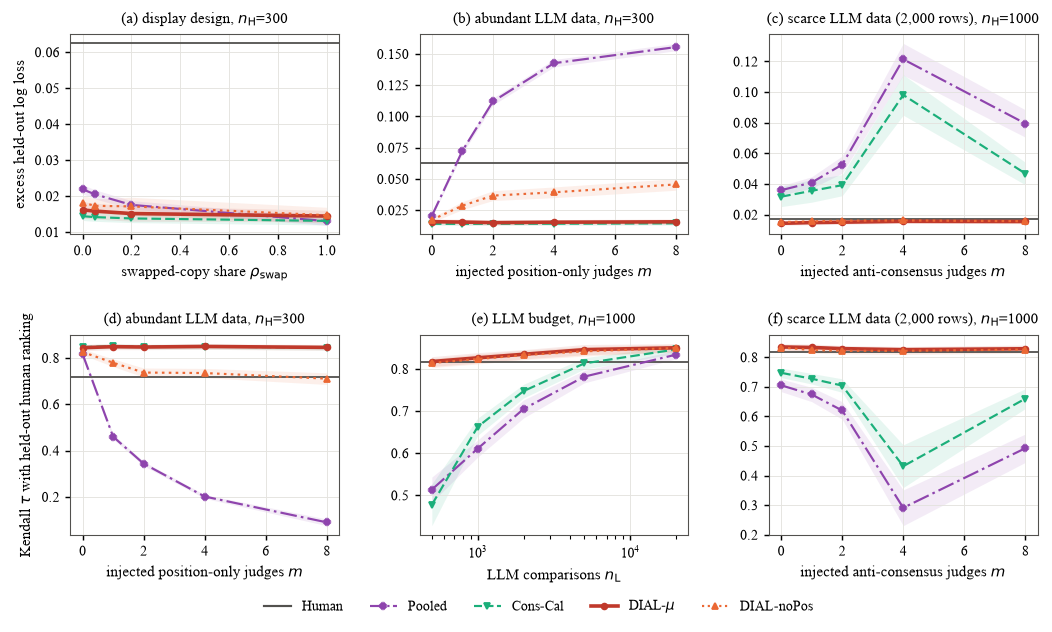

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(9.6, 5.0), gridspec_kw=dict(hspace=0.5, wspace=0.3))
if "arena_33k" in agg:
    a = agg["arena_33k"]
    panels = [  # (axes, sweep, kind, extra curve kwargs, x label, title)
        ((0, 0), "order", "none", {}, "swapped-copy share $\\rho_{\\mathrm{swap}}$", f"(a) display design, {NH}=300"),
        ((0, 1), "noise", "position", {}, "injected position-only judges $m$", f"(b) abundant LLM data, {NH}=300"),
        ((0, 2), "noise_scarce", "anti", {}, "injected anti-consensus judges $m$", f"(c) scarce LLM data (2,000 rows), {NH}=1000"),
        ((1, 0), "noise", "position", dict(metric="ref_kendall"), "injected position-only judges $m$", f"(d) abundant LLM data, {NH}=300"),
        ((1, 1), "llm_budget", "none", dict(metric="ref_kendall", n_H_level=1000, logx=True), "LLM comparisons $n_{\mathrm{L}}$", f"(e) LLM budget, {NH}=1000"),
        ((1, 2), "noise_scarce", "anti", dict(metric="ref_kendall"), "injected anti-consensus judges $m$", f"(f) scarce LLM data (2,000 rows), {NH}=1000"),
    ]
    for (i, j), sweep, kind, kw, xlab, title in panels:
        curve(axes[i, j], a, sweep, "biased5", kind, PRESENTED, **kw)
        axes[i, j].set_xlabel(xlab); axes[i, j].set_title(title, fontsize=8.5)
axes[0, 0].set_ylabel("excess held-out log loss"); axes[1, 0].set_ylabel("Kendall $\\tau$ with held-out human ranking")
h, l = legend_handles(PRESENTED, no_marker=("human_only",)); fig.legend(h, l, loc="lower center", ncol=5, frameon=False, bbox_to_anchor=(0.5, -0.03))
fig.savefig(FIGURES / "fig_real_curves.pdf", bbox_inches="tight"); plt.show()


## Appendix figure: human-record efficiency

Top: human budget with the as-collected balanced LLM data (all 21 judges); the LLM-anchored estimators sit at the LLM floor from a few hundred labels while human-only needs the full pool. Human is off the chart at the smallest budgets, where its MLE does not exist.
Bottom: LLM rows of the five position-sensitive judges subsampled to $n_{\mathrm{L}}$ at a fixed human budget, on the three benchmarks; with ten or fewer judgments per pair DIAL beats both the two-step consensus calibration and human-only. Dotted: the weight minimizing the test log loss.

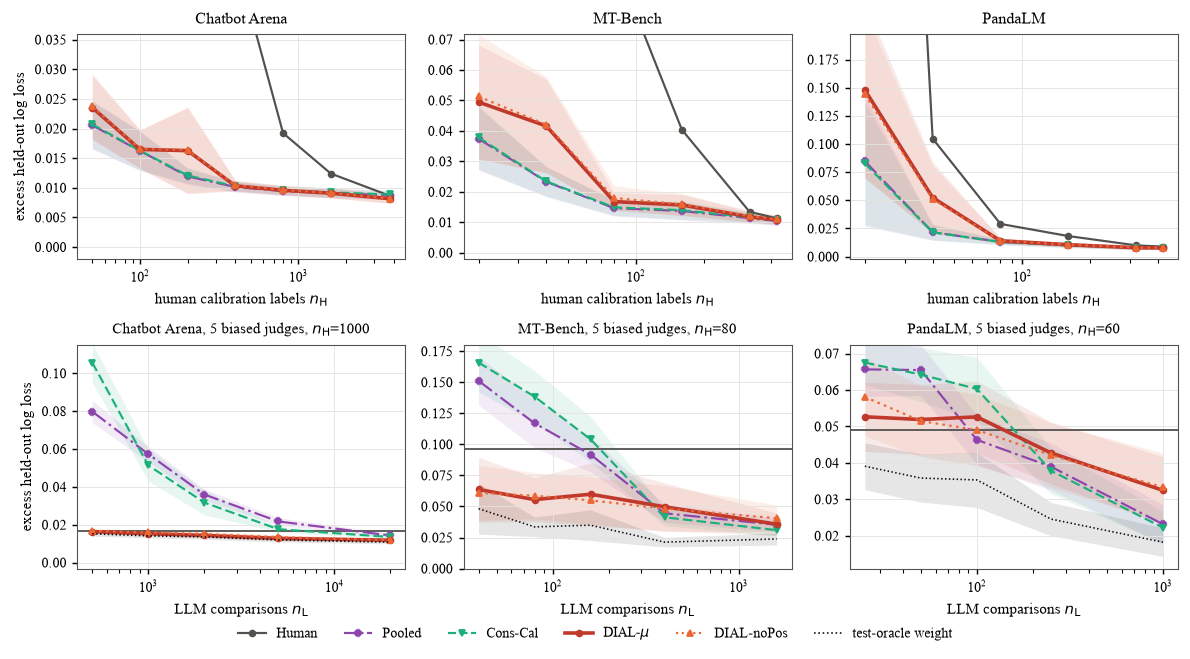

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(9.2, 4.9))
methods_C1 = list(PRESENTED)
for ax, d in zip(axes[0], DATASETS):
    if d in agg:
        curve(ax, agg[d], "budget", "all", "none", methods_C1, x="n_H", logx=True, hline_human=False)
        g = agg[d][(agg[d].sweep == "budget") & (agg[d].method != "human_only") & (agg[d].method.isin(methods_C1))]
        ax.set_ylim(min(g.excess_mean.min(), g.floor.mean() * 0) - 0.002, g.excess_mean.max() * 1.3 + 0.005)
    ax.set_title(DLAB[d]); ax.set_xlabel(f"human calibration labels {NH}")
axes[0, 0].set_ylabel("excess held-out log loss")
methods_C2 = list(PRESENTED) + ["oracle_test"]
for ax, d in zip(axes[1], DATASETS):
    if d in agg:
        curve(ax, agg[d], "llm_budget", "biased5", "none", methods_C2, n_H_level=NH_SCARCE[d], logx=True); clip_axis(ax, agg[d], "llm_budget", "biased5", "none", methods_C2, n_H_level=NH_SCARCE[d])
    ax.set_title(f"{DLAB[d]}, 5 biased judges, {NH}={NH_SCARCE[d]}", fontsize=8.5); ax.set_xlabel("LLM comparisons $n_{\mathrm{L}}$")
axes[1, 0].set_ylabel("excess held-out log loss")
h, l = legend_handles(methods_C2)
fig.legend(h, l, loc="lower center", ncol=8, frameon=False, bbox_to_anchor=(0.5, -0.03))
fig.tight_layout(); fig.savefig(FIGURES / "fig_real_efficiency.pdf", bbox_inches="tight"); plt.show()


## Appendix figure: budget planning from a pilot

From a pilot of $n_{\mathrm{pilot}}$ human labels, the specification-test statistic $T$ gives the point estimate $\widehat\Delta = \max\{0, (T - \mathrm{df})/(2n_{\mathrm{pilot}})\}$ and, by inverting the noncentral $\chi^2_{\mathrm{df}}$ distribution of $T$, a two-sided 90% interval $[\widehat\Delta_{\mathrm{lo}}, \widehat\Delta_{\mathrm{hi}}]$ for the anchor's misspecification $\Delta_W$.
Predicted excess (relative to the in-sample test-pool floor, whose optimism $(N-1)/(2n_{\mathrm{test}})$ is added back): anchored $\Delta + (r+1)/(2n)$ at the point estimate (line) and at the two interval ends (band); human-only $(N-1)/(2n)$; the crossover $n^\star=(N-r-2)/(2\Delta)$ is drawn at the point estimate (dashed) and as the interval implied by $[\widehat\Delta_{\mathrm{lo}}, \widehat\Delta_{\mathrm{hi}}]$ (grey span, open to the right when the lower end is zero).
All quantities are medians over the 50 pilots; the mean gives interval ends within 0.002 of the median ends, so the choice of aggregate no longer matters once the interval replaces the point estimate.
Observed curves are the 50-seed `budget` sweep (Cons-Cal and human-only).

## Appendix figure: W-calibration and weight diagnostics

(a, b) DIAL against DIAL-W (calibration within $W=[\mu,V]$ at the same LLM rank) and the fixed-weight fits, on the LLM-budget sweep (five biased judges, $n_{\mathrm{H}}=1{,}000$) and under injected anti-consensus judges in the scarce regime, Kendall $\tau$. (c) Share of seeds in which DIAL's GACV weight sits at each endpoint, and the median finite relative weight, against $n_{\mathrm{L}}$.

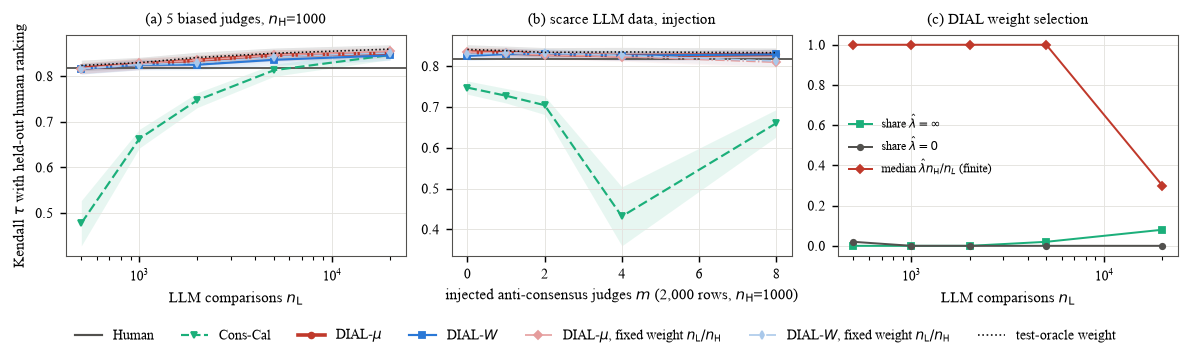

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(9.2, 2.5))
diag = ["human_only", "consensus_cal", "dial_mu", "dial_w", "dial_mle_mu", "dial_mle_w", "oracle_test"]

def tau_lines(ax, g):
    """Kendall's tau against the held-out human ranking, human-only as a flat reference line."""
    ax.axhline(g.loc[g.method == "human_only", "ref_kendall_mean"].mean(), color=STYLE["human_only"]["color"], lw=1.0)
    method_lines(ax, g, "level", "ref_kendall_mean", [m for m in diag if m != "human_only"], se="ref_kendall_se", band=True, ms=3)

if "arena_33k" in agg:
    a = agg["arena_33k"]
    tau_lines(axes[0], a[(a.sweep == "llm_budget") & (a.panel == "biased5") & (a.n_H_level == 1000)])
    axes[0].set_xscale("log"); axes[0].set_xlabel("LLM comparisons $n_{\mathrm{L}}$"); axes[0].set_ylabel("Kendall $\\tau$ with held-out human ranking"); axes[0].set_title(f"(a) 5 biased judges, {NH}=1000", fontsize=8.5)
    tau_lines(axes[1], a[(a.sweep == "noise_scarce") & (a.panel == "biased5") & (a.kind == "anti")])
    axes[1].set_xlabel(f"injected anti-consensus judges $m$ (2,000 rows, {NH}=1000)"); axes[1].set_title("(b) scarce LLM data, injection", fontsize=8.5)
    g = a[(a.sweep == "llm_budget") & (a.panel == "biased5") & (a.n_H_level == 1000) & (a.method == "dial_mu")].sort_values("level")
    for col, mk, color, lab in (("lam_inf_frac", "s", STYLE["consensus_cal"]["color"], "share $\\hat\\lambda=\\infty$"),
                                ("lam_zero_frac", "o", STYLE["human_only"]["color"], "share $\\hat\\lambda=0$"),
                                ("lam_rel_med", "D", STYLE["dial_mu"]["color"], "median $\\hat\\lambda n_{\\mathrm{H}}/n_L$ (finite)")):
        axes[2].plot(g.level, g[col].fillna(0), marker=mk, ms=3, lw=1.1, color=color, label=lab)
    axes[2].set_xscale("log"); axes[2].set_xlabel("LLM comparisons $n_{\mathrm{L}}$"); axes[2].set_title("(c) DIAL weight selection", fontsize=8.5); axes[2].legend(frameon=False, fontsize=6.5)
for ax in axes: ax.grid(True, color=GRID, lw=0.5)
h, l = legend_handles(diag, no_marker=("human_only",)); fig.legend(h, l, loc="lower center", ncol=7, frameon=False, bbox_to_anchor=(0.5, -0.1))
fig.tight_layout(); fig.savefig(FIGURES / "fig_real_diagnostics.pdf", bbox_inches="tight"); plt.show()


## Tables behind the figures

In [8]:
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 30)
for d in agg:
    for (sw, pn, kd), g in agg[d].groupby(["sweep", "panel", "kind"]):
        piv = g.pivot_table(index=["level", "n_H_level"], columns="method", values="excess_mean").reindex(columns=list(PRESENTED) + ["dial_w", "staged_w", "dial_mle_mu", "dial_mle_w", "oracle_test", "dial_rsel"])
        print(f"=== {DLAB[d]} | {sw} | panel={pn} | kind={kd}  (excess held-out log loss, mean over {int(g.n.max())} seeds)"); print(piv.round(4).to_string()); print()

=== Chatbot Arena | budget | panel=all | kind=none  (excess held-out log loss, mean over 50 seeds)
method             human_only  pooled_cal  consensus_cal  dial_mu  dial_nodeb  dial_w  staged_w  dial_mle_mu  dial_mle_w  oracle_test  dial_rsel
level   n_H_level                                                                                                                               
-1.0    -1             0.0086      0.0087         0.0089   0.0081      0.0082  0.0087    0.0090       0.0088      0.0089       0.0075     0.0085
 50.0   -1             6.6515      0.0205         0.0207   0.0235      0.0238  0.0466    0.0443       0.0207      0.0472       0.0201     0.0670
 100.0  -1             1.0170      0.0162         0.0163   0.0165      0.0166  0.0283    0.0213       0.0163      0.0216       0.0156     0.0228
 200.0  -1             0.2220      0.0119         0.0121   0.0163      0.0164  0.0253    0.0146       0.0121      0.0148       0.0116     0.0163
 400.0  -1             0.0489  